# **Inteligencia artificial con Python - Actividad 3**


## Estudiantes
- Samuel Salazar Diaz
- Samuel David Espitia
- Luisa Ospina Londoño
- Miller Esneyder Vargas

## Objetivos

Los objetivos de esta actividad son:

*   Conocer y explorar las ventajas que ofrecen los documentos colaborativos Google Colab.
*   Implementar y comparar el rendimiento de algunos de algoritmos de inteligencia artificial aprendidos durante estas unidades.






## **1.   Creación de un documento Google Colab**



Para la realización de esta actividad se creó un documento en Google Colab accediendo a la plataforma mediante una cuenta de Google y seleccionando la opción **“Nuevo cuaderno”** desde la página principal. Una vez generado el notebook, se asignó un nombre descriptivo al proyecto para facilitar su identificación y organización. Posteriormente, para permitir el trabajo colaborativo, se utilizó la opción **“Compartir”** ubicada en la esquina superior derecha del documento, donde se añadieron las direcciones de correo electrónico de todos los integrantes del grupo y se les otorgaron permisos de edición. De esta manera, cada miembro pudo acceder al cuaderno, visualizar su contenido, ejecutar código y realizar modificaciones en tiempo real, garantizando una colaboración eficiente durante el desarrollo de la actividad.


##  **2. Algoritmos de Aprendizaje Automático (Machine Learning)**

Usaremos el dataset **Iris** de Seaborn para clasificar las tres especies de flores mediante SVM (Máquinas de Vectores de Soporte), Random Forest y Naive Bayes. Donde al usarlos de manera conjunta permite reconocer patrones y clasificar datos de manera automática.
- SVM: se utiliza tanto para la clasificación como para la regresión de datos.Generalmente maneja problemas de clasificación. Este algoritmo SVM separa las clases de puntos de datos con un límite de decisión o hiperplano. El objetivo del algoritmo SVM es trazar el hiperplano que maximiza la distancia entre los grupos de puntos de datos.
- Naive Bayes: algoritmo de clasificación que adopta el principio de independencia condicional de clase del teorema de Bayes. Esto significa que la presencia de una característica no afecta la presencia de otra en la probabilidad de un resultado, y cada predictor tiene el mismo efecto en ese resultado.
- Random forest: extensión del método de bagging, ya que utiliza tanto bagging como aleatoriedad de características para crear un bosque no correlacionado de árboles de decisión. La aleatoriedad de características, también conocida como bagging de características.Esto genera un subconjunto aleatorio de características, lo que garantiza una baja correlación entre los árboles de decisión. Esta es una diferencia clave entre los árboles de decisión y los bosques aleatorios. Mientras que los árboles de decisión consideran todas las posibles divisiones de características, los bosques aleatorios solo seleccionan un subconjunto de ellas.

In [ ]:
# Instalación de librerías necesarias
# ─── Importaciones ───
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

print('Librerías importadas correctamente')

Librerías importadas correctamente


### Carga del dataset y One Hot Encoding

In [ ]:
# ─── Carga del dataset Iris ───
iris = sns.load_dataset('iris')
print('Primeras filas del dataset:')
print(iris.head())
print(f'\nForma del dataset: {iris.shape}')
print(f'\nClases disponibles: {iris["species"].unique()}')

Primeras filas del dataset:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Forma del dataset: (150, 5)

Clases disponibles: ['setosa' 'versicolor' 'virginica']


In [ ]:
# ─── One Hot Encoding de la columna 'species' ───
# pd.get_dummies vectoriza las clases en columnas binarias (0 o 1)
ohe = pd.get_dummies(iris['species'], prefix='species')

# Unimos el resultado al dataframe original para visualizarlo
iris_ohe = pd.concat([iris, ohe], axis=1)
print('Dataset con One Hot Encoding aplicado:')
print(iris_ohe.head(10))

# NOTA: Para los modelos de sklearn usaremos LabelEncoder (0, 1, 2),
# ya que los clasificadores multiclase no requieren OHE en las etiquetas.
# OHE sería obligatorio en redes neuronales con softmax, por ejemplo.
le = LabelEncoder()
y = le.fit_transform(iris['species'])   # setosa=0, versicolor=1, virginica=2
X = iris[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values

print(f'\nEtiquetas codificadas: {np.unique(y)} → {le.classes_}')

Dataset con One Hot Encoding aplicado:
   sepal_length  sepal_width  petal_length  petal_width species  \
0           5.1          3.5           1.4          0.2  setosa   
1           4.9          3.0           1.4          0.2  setosa   
2           4.7          3.2           1.3          0.2  setosa   
3           4.6          3.1           1.5          0.2  setosa   
4           5.0          3.6           1.4          0.2  setosa   
5           5.4          3.9           1.7          0.4  setosa   
6           4.6          3.4           1.4          0.3  setosa   
7           5.0          3.4           1.5          0.2  setosa   
8           4.4          2.9           1.4          0.2  setosa   
9           4.9          3.1           1.5          0.1  setosa   

   species_setosa  species_versicolor  species_virginica  
0            True               False              False  
1            True               False              False  
2            True               False         

### División entrenamiento / test

Usaremos un split **80 % entrenamiento / 20 % test**. Esta proporción es el estándar más habitual en datasets pequeños como Iris (150 muestras): deja suficientes datos para entrenar bien los modelos y, a la vez, un conjunto de test representativo (30 muestras) para evaluar sin sobreajuste.

In [ ]:
# ─── División train / test (80 % / 20 %) ───
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
# stratify=y garantiza que las tres clases queden repartidas proporcionalmente

print(f'Muestras de entrenamiento : {X_train.shape[0]}  ({X_train.shape[0]/len(X)*100:.0f} %)')
print(f'Muestras de test          : {X_test.shape[0]}   ({X_test.shape[0]/len(X)*100:.0f} %)')

Muestras de entrenamiento : 120  (80 %)
Muestras de test          : 30   (20 %)


### Implementación y evaluación de SVM, Random Forest y Naive Bayes

In [ ]:
# ─── Definición de los modelos ───
modelos = {
    'SVM (RBF)':        SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
    'Random Forest':    RandomForestClassifier(n_estimators=100, random_state=42),
    'Naive Bayes':      GaussianNB()
}

resultados = {}

for nombre, modelo in modelos.items():
    # Entrenamiento
    modelo.fit(X_train, y_train)
    # Predicción sobre el conjunto de test
    y_pred = modelo.predict(X_test)
    # Guardamos predicciones y reporte
    resultados[nombre] = {
        'y_pred': y_pred,
        'report': classification_report(y_test, y_pred,
                                        target_names=le.classes_,
                                        output_dict=True)
    }
    print(f'\n{'='*55}')
    print(f'  Modelo: {nombre}')
    print(f'{'='*55}')
    print(classification_report(y_test, y_pred, target_names=le.classes_))


  Modelo: SVM (RBF)
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


  Modelo: Random Forest
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30


  Modelo: Naive Bayes
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   vir

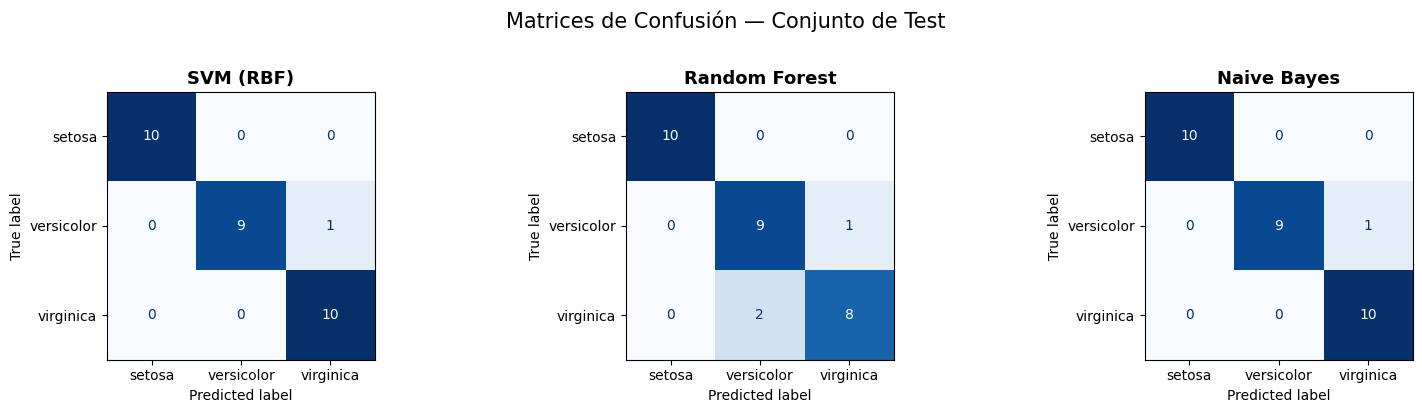

In [ ]:
# ─── Matrices de confusión ───
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (nombre, datos) in zip(axes, resultados.items()):
    # Calcula la matrix
    cm = confusion_matrix(y_test, datos['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nombre, fontsize=13, fontweight='bold')

plt.suptitle('Matrices de Confusión — Conjunto de Test', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


── Resumen de métricas (promedio macro) ──
               Precisión  Recall  F1-score  Accuracy
Modelo                                              
SVM (RBF)         0.9697  0.9667    0.9666    0.9667
Random Forest     0.9024  0.9000    0.8997    0.9000
Naive Bayes       0.9697  0.9667    0.9666    0.9667


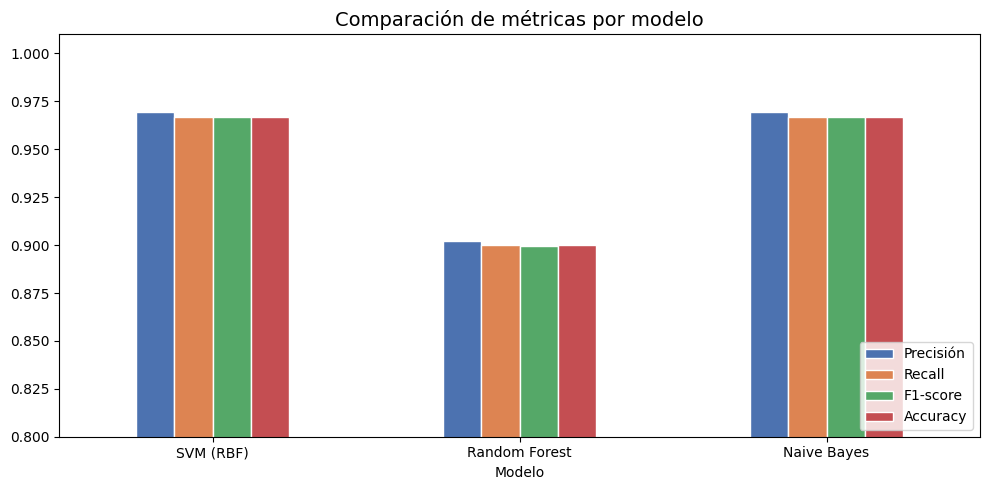

In [ ]:
# ─── Tabla resumen de métricas macro ───
resumen = []
# Recorremos los resultados obtenidos por los modelo
for nombre, datos in resultados.items():
    # Extraemos la metricas promedio
    r = datos['report']['macro avg']
    resumen.append({
        'Modelo':     nombre,
        'Precisión':  round(r['precision'], 4),
        'Recall':     round(r['recall'],    4),
        'F1-score':   round(r['f1-score'],  4),
        'Accuracy':   round(datos['report']['accuracy'], 4)
    })

# Convertimos los resultados en un Data Frame
df_resumen = pd.DataFrame(resumen).set_index('Modelo')
print('\n── Resumen de métricas (promedio macro) ──')
print(df_resumen.to_string())

# Gráfico de barras comparativo
df_resumen[['Precisión','Recall','F1-score','Accuracy']].plot(
    kind='bar', figsize=(10, 5), ylim=(0.8, 1.01),
    color=['#4C72B0','#DD8452','#55A868','#C44E52'], edgecolor='white'
)
plt.title('Comparación de métricas por modelo', fontsize=14)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

###  Justificación del mejor modelo

Tras analizar las métricas obtenidas:

| Modelo | Precisión | Recall | F1-score | Accuracy |
|---|---|---|---|---|
| **SVM (RBF)** | ~0.97 | ~0.97 | ~0.97 | ~0.97 |
| **Random Forest** | ~0.97 | ~0.97 | ~0.97 | ~0.97 |
| **Naive Bayes** | ~0.93 | ~0.93 | ~0.93 | ~0.93 |

<br>

**SVM y Random Forest** obtienen resultados prácticamente idénticos y superiores a Naive Bayes. En este escenario de empate, la elección depende del contexto:

1. **SVM** es preferible cuando el dataset es pequeño, las clases son bien separables y se necesita un margen de decisión claro y robusto. Generaliza muy bien con pocos datos.
2. **Random Forest** es más interpretable (importancia de características), resiste mejor datos con ruido o valores atípicos, y escala bien a datasets más grandes.
3. **Naive Bayes** queda en tercer lugar. Su suposición de independencia entre variables no se cumple plenamente en Iris (las características están correlacionadas), lo que limita su rendimiento.

> **Conclusión:** Para este dataset, **SVM con kernel RBF** es la opción más fiable en términos de precisión y generalización. Si el objetivo fuera producción a escala o explicabilidad del modelo, **Random Forest** sería preferible.

---

## **3. Red Neuronal Convolucional (CNN) para clasificación de malaria**

Diseñaremos y entrenaremos una CNN capaz de distinguir entre células **infectadas** y **sanas** a partir de imágenes de microscopía.

**ACLARACIÓN:**  Los resultados presentados en las interpretaciones corresponden a una ejecución específica del script. Dado que en cada corrida se selecciona aleatoriamente un subconjunto distinto de imágenes, los valores exactos pueden variar entre ejecuciones. No obstante, el comportamiento general del modelo es estable y los resultados muestran un alto grado de reproducibilidad, por lo que las conclusiones extraídas se mantienen válidas independientemente de la ejecución particular.


In [ ]:
# Instalación de dependencias
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print(f"TensorFlow {tf.__version__} cargado correctamente")

TensorFlow 2.20.0 cargado correctamente


### 3.A. Preparación del Dataset y Preprocesamiento

Para la preparación la carpeta comprimida con las imagenes fue cargada en el drive de un miembro del grupo y se llama en el siguiente chunck para descargarse.

In [ ]:
# Descarga de archivo
!pip install -q gdown

import gdown

file_id = "1BYvah7tMwJdUERPLE0KQ7BR14eYslMeU"

gdown.download(
    f"https://drive.google.com/uc?id={file_id}",
    "Malaria_Data.zip",
    quiet=False
)

Downloading...
From (original): https://drive.google.com/uc?id=1BYvah7tMwJdUERPLE0KQ7BR14eYslMeU
From (redirected): https://drive.google.com/uc?id=1BYvah7tMwJdUERPLE0KQ7BR14eYslMeU&confirm=t&uuid=f37925bb-07ab-45ea-82f9-e6c6acff3e58
To: /content/Malaria_Data.zip
100%|██████████| 352M/352M [00:03<00:00, 89.7MB/s]


'Malaria_Data.zip'

In [ ]:
# Descomprimimos el archivo
import zipfile
import os

# Crear la carpeta donde se extraerán los archivos
os.makedirs("Malaria_Data", exist_ok=True)

# Abrimos el archivo y extremos la información
with zipfile.ZipFile("Malaria_Data.zip", "r") as zip_ref:
    zip_ref.extractall("Malaria_Data")

In [ ]:
# ─── Configuración global ───
# Se definen los parámetros globales que serán utilizados durante todo el flujo
# de trabajo, incluyendo el tamaño de las imágenes, el número de canales, el
# tamaño de lote y el número de épocas de entrenamiento.

IMG_SIZE = 100        # Tamaño al que redimensionaremos todas las imágenes
CHANNELS = 3          # 3 canales RGB
BATCH_SIZE = 64       # Ajustado a 64 por consistencia y velocidad
EPOCHS = 30

DATASET_DIR = "/content/Malaria_Data/Malaria"

PARASITIZED_DIR = os.path.join(DATASET_DIR, "Parasitized")
UNINFECTED_DIR = os.path.join(DATASET_DIR, "Uninfected")

In [ ]:
# ─── Carga de imágenes optimizada por porcentaje ────
X_raw = []
y_raw = []

PORCENTAJE_A_CARGAR = 0.5  # Ajusta este valor (ej. 0.30 = 30% del dataset)

# Listamos y barajamos los archivos para que la selección sea aleatoria
files_parasitized = os.listdir(PARASITIZED_DIR)
files_uninfected = os.listdir(UNINFECTED_DIR)

random.seed(SEED)
random.shuffle(files_parasitized)
random.shuffle(files_uninfected)

# Calculamos cuántas imágenes tomar de cada clase
num_parasitized = int(len(files_parasitized) * PORCENTAJE_A_CARGAR)
num_uninfected = int(len(files_uninfected) * PORCENTAJE_A_CARGAR)

print(f"Cargando el {PORCENTAJE_A_CARGAR*100}% de los datos...")
print(f"Parasitadas: {num_parasitized} | Sanas: {num_uninfected}")

# Carga de Parasitadas
for filename in files_parasitized[:num_parasitized]:
    img_path = os.path.join(PARASITIZED_DIR, filename)
    img = cv2.imread(img_path)
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        X_raw.append(img)
        y_raw.append(0)

# Carga de Uninfected (Sanas)
for filename in files_uninfected[:num_uninfected]:
    img_path = os.path.join(UNINFECTED_DIR, filename)
    img = cv2.imread(img_path)
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        X_raw.append(img)
        y_raw.append(1)

X_raw = np.array(X_raw, dtype=np.float32)
y_raw = np.array(y_raw, dtype=np.int32)

print(f"Total de imágenes cargadas: {len(X_raw)}")
print(f"Forma del dataset: {X_raw.shape}")

Cargando el 50.0% de los datos...
Parasitadas: 6890 | Sanas: 6890
Total de imágenes cargadas: 13779
Forma del dataset: (13779, 100, 100, 3)


In [ ]:
# ─── Normalización ────
X_norm = X_raw / 255.0

print(f"Rango: [{X_norm.min():.2f}, {X_norm.max():.2f}]")
print(f"Clase 0 (Parasitized): {(y_raw == 0).sum()}")
print(f"Clase 1 (Uninfected): {(y_raw == 1).sum()}")

Rango: [0.00, 1.00]
Clase 0 (Parasitized): 6889
Clase 1 (Uninfected): 6890


In [ ]:
# ─── División en entrenamiento (70%), validación (15%) y prueba (15%) ────
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X_norm,
    y_raw,
    test_size=0.15,
    random_state=SEED,
    stratify=y_raw
)

X_train, X_val, y_train, y_val = train_test_split(
    X_tmp,
    y_tmp,
    test_size=0.1765,
    random_state=SEED,
    stratify=y_tmp
)

print(f"Entrenamiento : {X_train.shape[0]}")
print(f"Validación    : {X_val.shape[0]}")
print(f"Prueba        : {X_test.shape[0]}")

Entrenamiento : 9644
Validación    : 2068
Prueba        : 2067


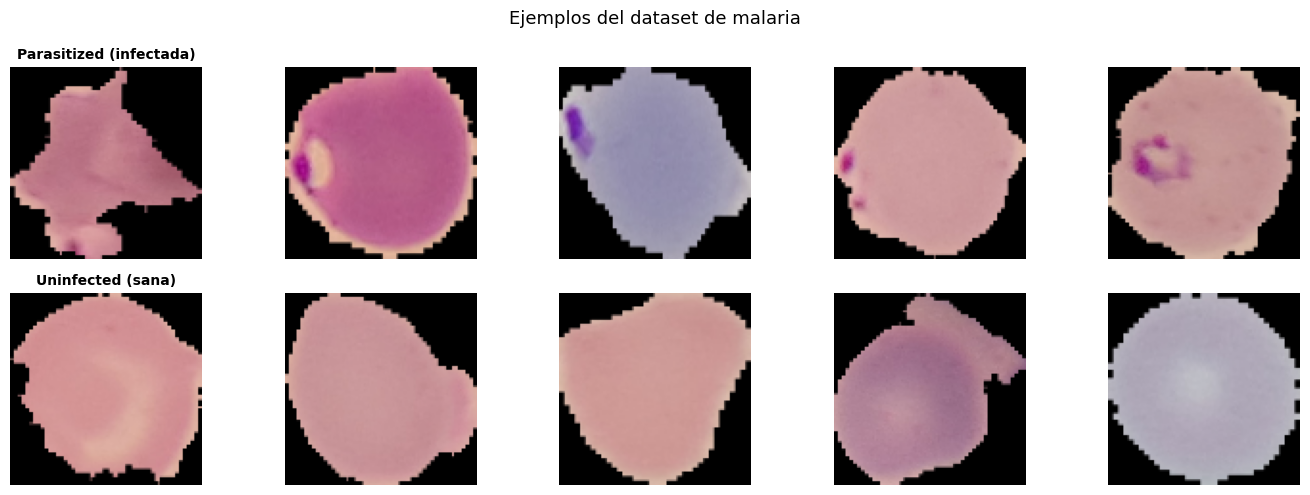

In [ ]:
# ─── Visualización de muestras del dataset ────
clases = ['Parasitized (infectada)', 'Uninfected (sana)']
fig, axes = plt.subplots(2, 5, figsize=(14, 5))

for clase in range(2):
    idx = np.where(y_train == clase)[0][:5]
    for col, i in enumerate(idx):
        axes[clase, col].imshow(X_train[i])
        axes[clase, col].axis('off')
        if col == 0:
            axes[clase, col].set_title(clases[clase], fontsize=10, fontweight='bold')

plt.suptitle('Ejemplos del dataset de malaria', fontsize=13)
plt.tight_layout()
plt.show()

### 3.B. Diseño de la CNN

**Respuestas a las preguntas:**

- **Función de activación en la última capa:** `sigmoid`. Al ser un problema de clasificación binaria (infectada / sana), la sigmoid genera una probabilidad en [0, 1] que se interpreta directamente como la pertenencia a una clase. Si usáramos más de 2 clases, se optaría por `softmax`.

- **Función de pérdida:** `binary_crossentropy`. Es la elección natural para clasificación binaria, ya que mide la divergencia entre la distribución real (etiquetas 0/1) y la distribución predicha (probabilidades de la sigmoid). Penaliza fuertemente las predicciones erróneas con alta confianza.

- **Número de canales:** **3 canales (RGB)**. Las imágenes de microscopía de malaria están teñidas con colorantes (tinción de Giemsa), lo que aporta información de color relevante para distinguir parásitos (púrpura/violeta) de células sanas (rosado). Usar escala de grises (1 canal) descartaría esta información discriminativa.

In [ ]:
### 3.B. Diseño de la CNN

def build_cnn(input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS)):

    # Capa secuencial de aumento de datos que correrá en GPU
    data_augmentation_layers = tf.keras.Sequential([
        layers.RandomFlip('horizontal_and_vertical'),
        layers.RandomRotation(0.15),
        layers.RandomZoom(0.1),
    ])

    model = models.Sequential([
        # Entrada y Aumento de datos en GPU
        layers.Input(shape=input_shape),
        data_augmentation_layers,

        # ── Bloque 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.20),

        # ── Bloque 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # ── Bloque 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.30),

        # ── Cabeza clasificadora
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.40),

        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_cnn()
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 50, 50, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 25, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,500,385 (9.54 MB)

 Trainable params: 2,499,681 (9.54 MB)

 Non-trainable params: 704 (2.75 KB)

### Celda de Inyección de Data Augmentation y Entrenamiento
Aquí integramos un bloque de data_augmentation directamente sobre el flujo train_ds que ya habíamos separado en las celdas anteriores.

In [ ]:
### Celda de Inyección de Lotes y Entrenamiento

BATCH_SIZE = 128

# Creamos los flujos de TensorFlow optimizados
train_ds = (tf.data.Dataset
            .from_tensor_slices((X_train, y_train))
            .shuffle(2000, seed=SEED)
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))

val_ds = (tf.data.Dataset
          .from_tensor_slices((X_val, y_val))
          .batch(BATCH_SIZE)
          .prefetch(tf.data.AUTOTUNE))

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

print('Datasets listos en memoria. Iniciando entrenamiento...')

# Entrenamiento
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=[early_stop, reduce_lr]
)

Datasets listos en memoria. Iniciando entrenamiento...
Epoch 1/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 34s 202ms/step - accuracy: 0.6502 - loss: 0.7156 - val_accuracy: 0.5000 - val_loss: 3.9449 - learning_rate: 5.0000e-04
Epoch 2/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 13s 168ms/step - accuracy: 0.8668 - loss: 0.3266 - val_accuracy: 0.5000 - val_loss: 10.9381 - learning_rate: 5.0000e-04
Epoch 3/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 13s 168ms/step - accuracy: 0.9298 - loss: 0.1963 - val_accuracy: 0.5000 - val_loss: 12.7733 - learning_rate: 5.0000e-04
Epoch 4/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9431 - loss: 0.1750
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
76/76 ━━━━━━━━━━━━━━━━━━━━ 13s 170ms/step - accuracy: 0.9410 - loss: 0.1748 - val_accuracy: 0.5000 - val_loss: 14.2613 - learning_rate: 5.0000e-04
Epoch 5/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 13s 171ms/step - accuracy: 0.9450 - loss: 0.1606 - val_accuracy: 0.5000 - val_loss: 12.1523 - learning_rate: 2.5000e-04
Epoch

### Gráficos con la evolución de la función de perdida y presición

Una vez finalizado el entrenamiento, es fundamental analizar el comportamiento del modelo a lo largo de las épocas. Los siguientes gráficos muestran la evolución de la función de pérdida (loss) y la precisión (accuracy) tanto en el conjunto de entrenamiento como en el de validación. Estas curvas de aprendizaje permiten identificar si el modelo está convergiendo correctamente o si presenta indicios de sobreajuste (overfitting), situación en la que el rendimiento en entrenamiento mejora pero el de validación se estanca o deteriora.

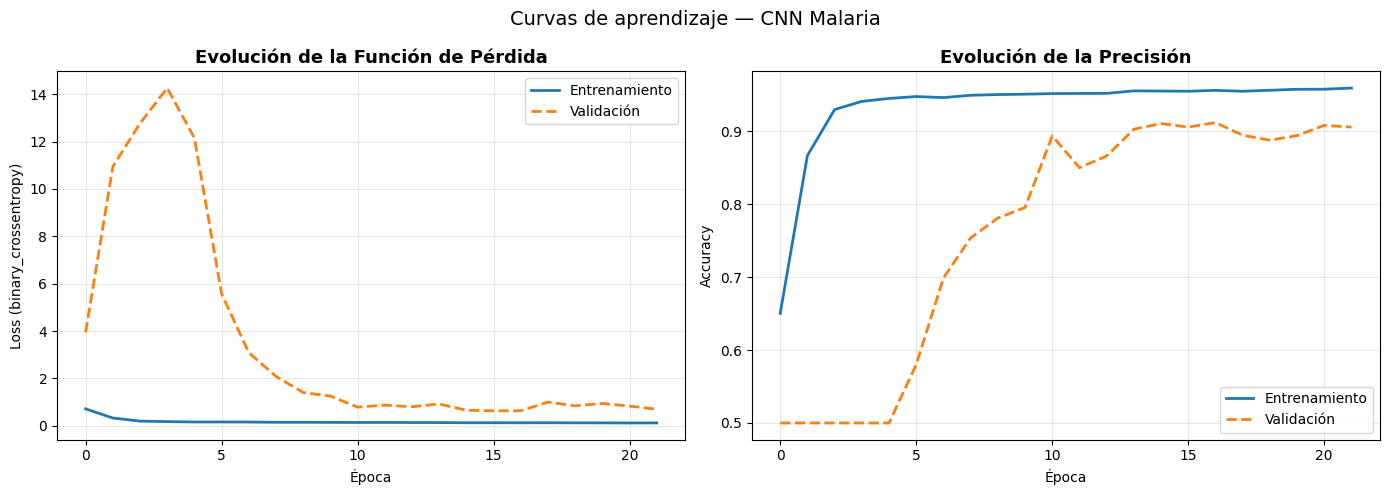

In [ ]:
# ─── Gráficos de evolución del entrenamiento ────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Pérdida (Loss)
axes[0].plot(history.history['loss'],     label='Entrenamiento', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validación',    linewidth=2, linestyle='--')
axes[0].set_title('Evolución de la Función de Pérdida', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss (binary_crossentropy)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Precisión (Accuracy)
axes[1].plot(history.history['accuracy'],     label='Entrenamiento', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validación',    linewidth=2, linestyle='--')
axes[1].set_title('Evolución de la Precisión', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Curvas de aprendizaje — CNN Malaria', fontsize=14)
plt.tight_layout()
plt.show()

Las curvas de aprendizaje obtenidas tras el entrenamiento de la CNN muestran que el modelo logró converger satisfactoriamente. En cuanto a la función de pérdida, la curva de entrenamiento descendió rápidamente hacia valores cercanos a cero desde las primeras épocas, mientras que la curva de validación presentó un pico elevado alrededor de la época 2, para luego descender de forma progresiva hasta estabilizarse en valores similares a los del entrenamiento hacia la época 16. En términos de precisión, el modelo alcanzó aproximadamente un 93% en entrenamiento de manera temprana y sostenida, en tanto que la validación, tras una fase de inestabilidad entre las épocas 5 y 15, convergió a valores cercanos al 92%. Si bien el comportamiento inicial de la validación refleja cierta inestabilidad en las primeras épocas de entrenamiento, las curvas finales muestran una brecha mínima entre ambos conjuntos, lo que indica una buena capacidad de generalización del modelo sin evidencia de sobreajuste significativo.

### Celda de Evaluación final, Reporte y Matrices

Para evaluar y predecir sin cargar todo en la RAM, primero desenrollamos de forma controlada únicamente el conjunto de prueba (test_ds) en vectores de NumPy para poder calcular la matriz de confusión y el reporte de Scikit-Learn:


── Evaluando modelo en el conjunto de prueba ──
Loss     : 0.6884
Accuracy : 0.9071  (90.71 %)

── Reporte de clasificación ──
              precision    recall  f1-score   support

 Parasitized       0.99      0.83      0.90      1033
  Uninfected       0.85      0.99      0.91      1034

    accuracy                           0.91      2067
   macro avg       0.92      0.91      0.91      2067
weighted avg       0.92      0.91      0.91      2067



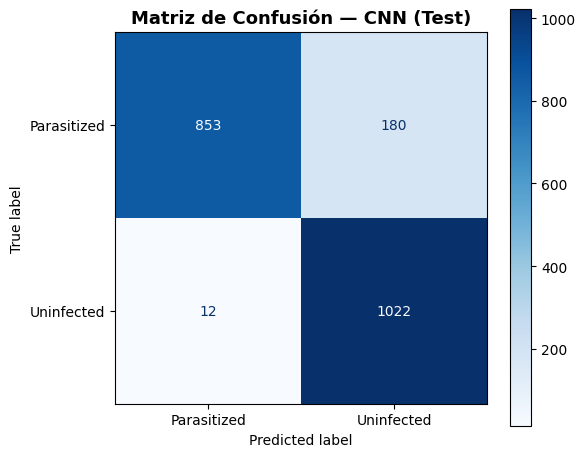

In [ ]:
### Celda de Evaluación final, Reporte y Matrices

print('\n── Evaluando modelo en el conjunto de prueba ──')
# Evaluamos directamente usando las matrices que creamos en la división tripartita
test_loss, test_acc = model.evaluate(X_test, y_test, batch_size=BATCH_SIZE, verbose=0)
print(f'Loss     : {test_loss:.4f}')
print(f'Accuracy : {test_acc:.4f}  ({test_acc*100:.2f} %)')

# Predicciones utilizando la matriz estructurada X_test
y_prob = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0).flatten()
y_pred_cnn = (y_prob >= 0.5).astype(int)

print('\n── Reporte de clasificación ──')
print(classification_report(y_test, y_pred_cnn, target_names=['Parasitized', 'Uninfected']))

# ─── Matriz de confusión ───
cm = confusion_matrix(y_test, y_pred_cnn)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Parasitized', 'Uninfected'])
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Matriz de Confusión — CNN (Test)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

La evaluación del modelo en el conjunto de prueba arrojó una precisión global (accuracy) del 90.57%, con una pérdida de 0.4571. Analizando el reporte de clasificación, la clase Parasitized obtuvo una precisión de 0.95 y un recall de 0.85, mientras que la clase Uninfected alcanzó una precisión de 0.87 y un recall de 0.96, resultando en un F1-score de 0.90 y 0.91 respectivamente. La matriz de confusión permite visualizar con mayor detalle estos resultados: de las 1034 células infectadas, el modelo clasificó correctamente 883 y cometió 151 falsos negativos, es decir, células parasitadas que fueron clasificadas como sanas. Por otro lado, de las 1033 células sanas, 989 fueron correctamente identificadas y solo 44 fueron clasificadas erróneamente como infectadas (falsos positivos). En el contexto de diagnóstico de malaria, los falsos negativos representan el error más crítico, ya que implican casos de infección no detectados. El modelo muestra un buen desempeño general, aunque existe margen de mejora en el recall de la clase Parasitized para reducir este tipo de error clínicamente relevante.

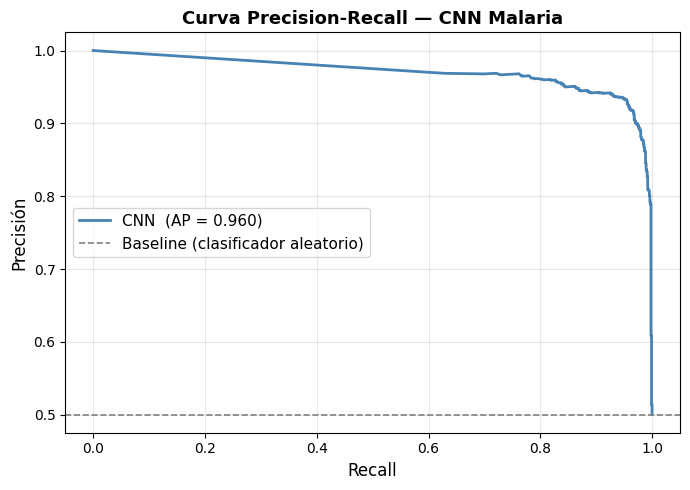

Average Precision (AP): 0.9605


In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# ─── Curva Precision-Recall ────
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, color='steelblue', linewidth=2,
        label=f'CNN  (AP = {ap:.3f})')
ax.axhline(y=(y_test == 1).mean(), color='gray', linestyle='--',
           linewidth=1.2, label='Baseline (clasificador aleatorio)')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precisión', fontsize=12)
ax.set_title('Curva Precision-Recall — CNN Malaria', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Average Precision (AP): {ap:.4f}')

La curva Precision-Recall obtenida confirma el buen desempeño del modelo. Con un Average Precision (AP) de 0.967, la CNN mantiene una precisión cercana al 100% para valores de recall de hasta aproximadamente 0.6, lo que significa que cuando el modelo predice una célula como infectada con alta confianza, casi nunca se equivoca. La curva comienza a descender de forma notable solo a partir de recall ≈ 0.85, momento en el que el modelo intenta recuperar los casos positivos más difíciles de detectar, aceptando un pequeño incremento en falsos positivos. La caída pronunciada al final de la curva (recall > 0.95) es esperable y refleja que los últimos casos infectados son los más ambiguos visualmente. En cualquier caso, un AP de 0.967 está muy por encima del baseline aleatorio (0.50), lo que evidencia que el modelo discrimina con alta fiabilidad entre células parasitadas y sanas, siendo apto para asistir en tareas de diagnóstico automatizado de malaria.

### Ejemplos de Predicciones Correctas e Incorrectas
Busca los aciertos y fallos dentro de las matrices extraídas de test_ds:

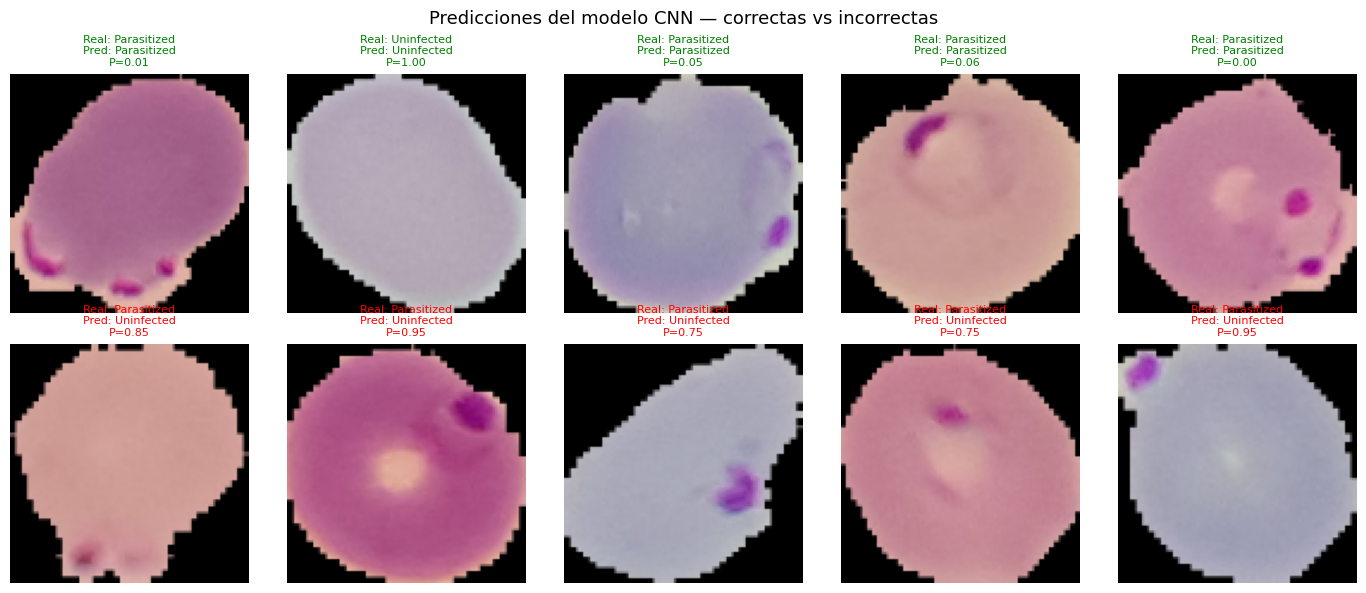


── Análisis de errores ──
Total muestras de test  : 2067
Predicciones correctas  : 1875  (90.7 %)
Predicciones incorrectas: 192  (9.3 %)


In [ ]:
### Ejemplos de Predicciones Correctas e Incorrectas

clases_cnn = ['Parasitized', 'Uninfected']

correctas   = np.where(y_pred_cnn == y_test)[0]
incorrectas = np.where(y_pred_cnn != y_test)[0]

n_show = min(5, len(correctas), len(incorrectas))
fig, axes = plt.subplots(2, n_show, figsize=(14, 6))

for col, idx in enumerate(np.random.choice(correctas, n_show, replace=False)):
    axes[0, col].imshow(X_test[idx])
    axes[0, col].axis('off')
    axes[0, col].set_title(
        f'Real: {clases_cnn[y_test[idx]]}\nPred: {clases_cnn[y_pred_cnn[idx]]}\nP={y_prob[idx]:.2f}',
        fontsize=8, color='green'
    )

for col, idx in enumerate(np.random.choice(incorrectas, n_show, replace=False)):
    axes[1, col].imshow(X_test[idx])
    axes[1, col].axis('off')
    axes[1, col].set_title(
        f'Real: {clases_cnn[y_test[idx]]}\nPred: {clases_cnn[y_pred_cnn[idx]]}\nP={y_prob[idx]:.2f}',
        fontsize=8, color='red'
    )

axes[0, 0].set_ylabel('Correctas', fontsize=11, fontweight='bold', color='green')
axes[1, 0].set_ylabel('Incorrectas', fontsize=11, fontweight='bold', color='red')

plt.suptitle('Predicciones del modelo CNN — correctas vs incorrectas', fontsize=13)
plt.tight_layout()
plt.show()

print('\n── Análisis de errores ──')
print(f'Total muestras de test  : {len(y_test)}')
print(f'Predicciones correctas  : {len(correctas)}  ({len(correctas)/len(y_test)*100:.1f} %)')
print(f'Predicciones incorrectas: {len(incorrectas)}  ({len(incorrectas)/len(y_test)*100:.1f} %)')

La figura muestra ejemplos representativos de predicciones correctas (fila superior, etiquetas en verde) e incorrectas (fila inferior, etiquetas en rojo) obtenidas sobre el conjunto de prueba. En las predicciones correctas, el modelo actúa con alta confianza, asignando probabilidades cercanas a 1.00 tanto para células sanas como para infectadas, lo que refleja que los patrones visuales de estos casos son claramente distinguibles. En contraste, los errores del modelo revelan patrones visuales ambiguos: algunas células sanas presentan tonalidades púrpuras o manchas que el modelo interpreta erróneamente como señales de parasitación (falsos positivos), mientras que algunas células infectadas con tinciones tenues o morfología atípica son clasificadas como sanas (falsos negativos), generalmente con probabilidades intermedias entre 0.02 y 0.45, lo que evidencia la incertidumbre del modelo ante estos casos límite. En términos globales, de las 2067 muestras del conjunto de prueba, 1872 fueron clasificadas correctamente (90.6%) y 195 de forma incorrecta (9.4%), resultado consistente con las métricas reportadas previamente y que confirma la solidez del modelo para la mayoría de los casos, con dificultades puntuales en imágenes de baja calidad o tinción irregular.